In [1]:
import pandas as pd

dumb_cargoterminal_loadshifting = pd.read_excel(
    "outputs/dumb_cargoterminal_loadshifting.xlsx"
)
cargoterminal_loadshifting = pd.read_excel("outputs/cargoterminal_loadshifting.xlsx")

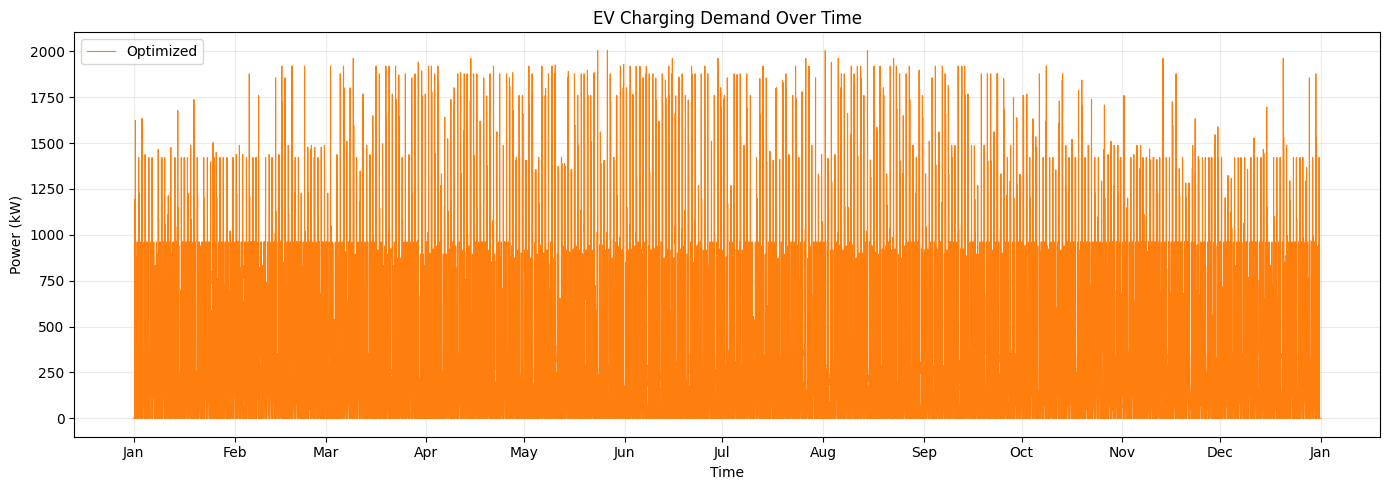

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(cargoterminal_loadshifting["datetime"])
ev_non_optimized = dumb_cargoterminal_loadshifting["EV_charging_kw"]
ev_optimized = cargoterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    time,
    ev_optimized,
    color="#ff7f0e",
    linewidth=0.8,
    label="Optimized",
)

ax.set_title("EV Charging Demand Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

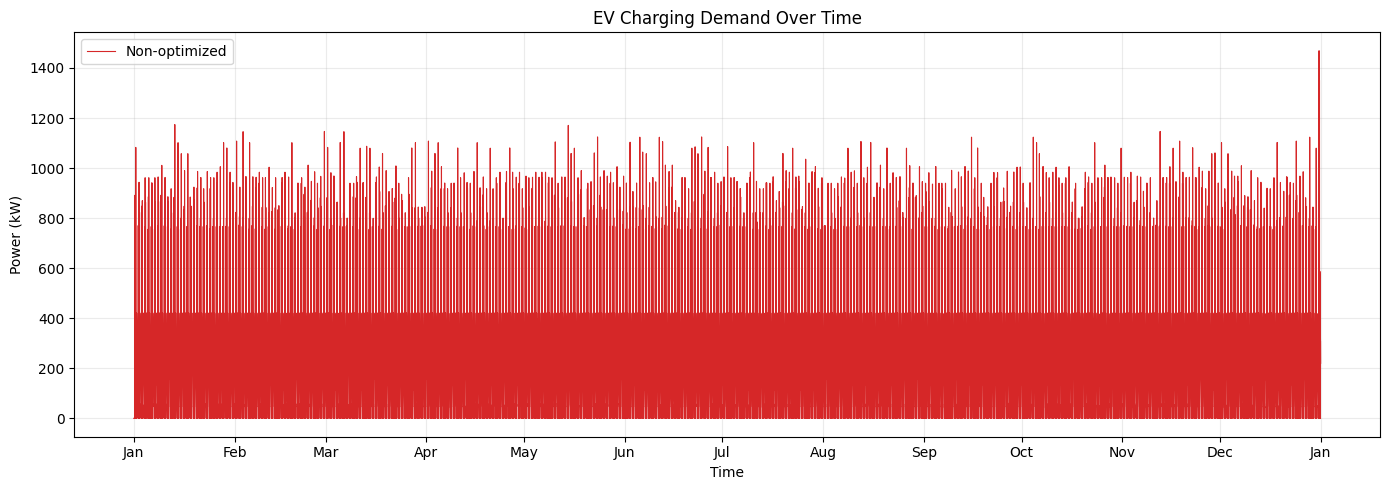

In [3]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(cargoterminal_loadshifting["datetime"])
ev_non_optimized = dumb_cargoterminal_loadshifting["EV_charging_kw"]
ev_optimized = cargoterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    time,
    ev_non_optimized,
    color="#d62728",
    linewidth=0.8,
    label="Non-optimized",
)

ax.set_title("EV Charging Demand Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

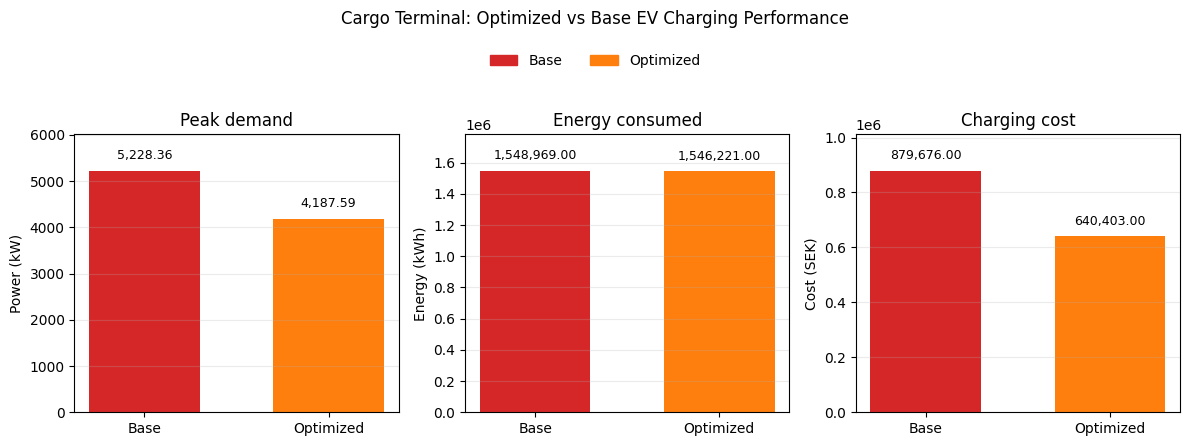

In [1]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Peak demand", "Energy consumed", "Charging cost"]
optimized = [4187.59, 1546221, 640403]
base = [5228.36, 1548969, 879676]
y_labels = ["Power (kW)", "Energy (kWh)", "Cost (SEK)"]
scenario_labels = ["Base", "Optimized"]
colors = ["#d62728", "#ff7f0e"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharex=False)

for ax, metric, opt, base_value, y_label in zip(
    axes, metrics, optimized, base, y_labels
):
    values = [base_value, opt]
    bars = ax.bar(scenario_labels, values, color=colors, width=0.6)
    ax.set_title(metric)
    ax.set_ylabel(y_label)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, max(values) * 1.15)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:,.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            clip_on=False,
        )

fig.suptitle("Cargo Terminal: Optimized vs Base EV Charging Performance", y=0.98)
fig.legend(
    [plt.Rectangle((0, 0), 1, 1, color=color) for color in colors],
    scenario_labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 0.91),
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()

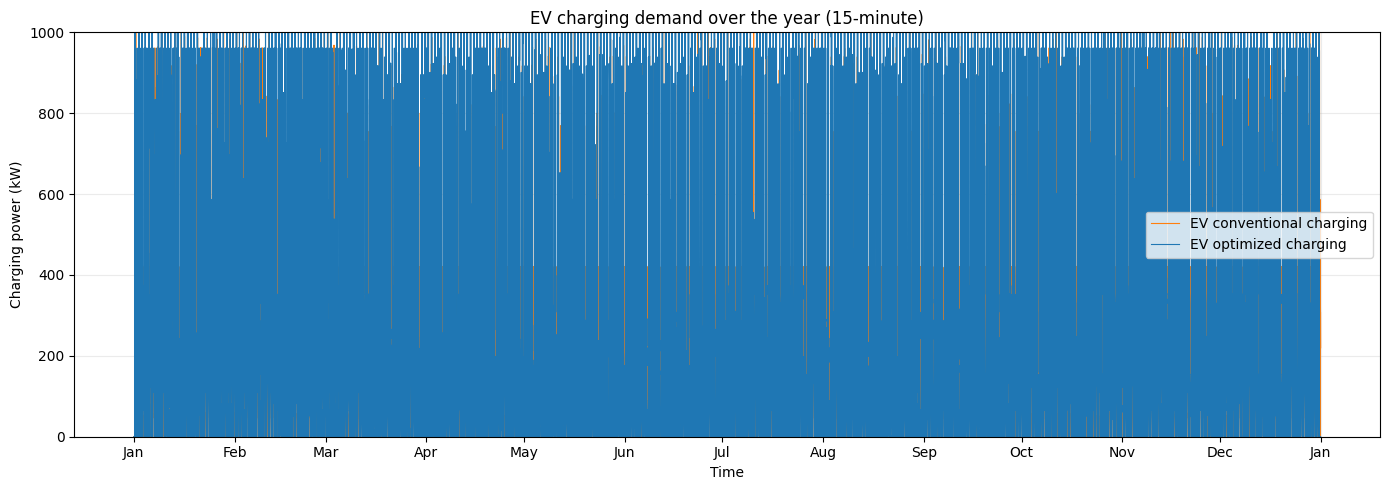

In [5]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

time = pd.to_datetime(cargoterminal_loadshifting["datetime"])
ev_dumb = dumb_cargoterminal_loadshifting["EV_charging_kw"]
ev_optimized = cargoterminal_loadshifting["EV_charging_kw"]

fig, ax = plt.subplots(figsize=(14, 5))

# Dumb charging (orange)
ax.plot(
    time,
    ev_dumb,
    color="#ff7f0e",
    linewidth=0.8,
    label="EV conventional charging",
)

# Optimized charging
ax.plot(
    time,
    ev_optimized,
    color="#1f77b4",
    linewidth=0.8,
    label="EV optimized charging",
)

ax.set_title("EV charging demand over the year (15-minute)")
ax.set_xlabel("Time")
ax.set_ylabel("Charging power (kW)")
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax.set_ylim(0, 1000)

plt.tight_layout()
plt.show()